<a href="https://colab.research.google.com/github/muratmelek08/yolov8-brain-tumor-detection/blob/main/YOLOv8_Tabanl%C4%B1_Derin_%C3%96%C4%9Frenme_Yakla%C5%9F%C4%B1mlar%C4%B1yla_Beyin_T%C3%BCm%C3%B6r%C3%BC_Tespiti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ultralytics

In [ ]:
import urllib.request
import zipfile
import os

# Veri setini indirme
url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip"
urllib.request.urlretrieve(url, "brain-tumor.zip")

# Zip dosyasını çıkarma
with zipfile.ZipFile("brain-tumor.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets") # YOLO genelde datasets klasörü arar

In [ ]:
# ==============================================================================
# 1. ADIM: Google Drive Bağlantısı (Dosyaların uçmaması için)
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

# ==============================================================================
# 2. ADIM: Kütüphane ve Hocanın İstediği Nano Modelin Yüklenmesi
# ==============================================================================
from ultralytics import YOLO

# Hocanın dökümanındaki kesin kural: YOLOv8 Nano modelini yüklüyoruz
model = YOLO("yolov8n.pt")

# ==============================================================================
# 3. ADIM: İzin Verilen Parametrelerle Optimizasyon ve Eğitim
# ==============================================================================
results = model.train(
    data="datasets/brain-tumor.yaml",
    model="yolov8n.pt", # Mimari kesinlikle Nano kalıyor
    imgsz=640,
    plots=True,

    # --- DEĞİŞTİRİLMESİNE İZİN VERİLEN VE BAŞARIYI ARTIRAN AYARLAR ---
    epochs=100,         # Öğrenme kalitesini artırmak için epoch sayısını 100 yapıyoruz.
    mosaic=0.0,         # Tıbbi MR yapısını korumak için veri artırım modifikasyonu.

    # --- GOOGLE DRIVE KALICI KAYIT AYARLARI ---
    project="/content/drive/MyDrive/Beyin_Tumoru_Projesi",
    name="YOLOv8n_Hoca_Kisitli_Optimize_Model"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosai


[TEST] Analiz Edilen Rastgele Resim: datasets/brain-tumor/images/val/val_1 (7).jpg


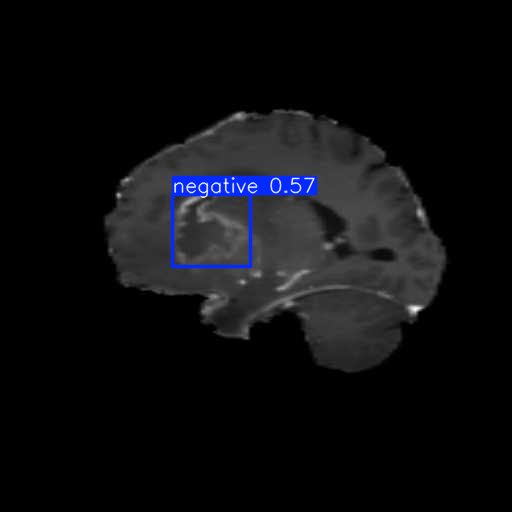

In [ ]:
import os
import random
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. En son eğittiğimiz kalıcı "En İyi" model ağırlıklarının güncel yolu
model_yolu = "/content/drive/MyDrive/Beyin_Tumoru_Projesi/YOLOv8n_Hoca_Kisitli_Optimize_Model/weights/best.pt"
best_model = YOLO(model_yolu)

# 2. Doğrulama resimlerinin bulunduğu klasör
val_klasoru = "datasets/brain-tumor/images/val"

# 3. Klasördeki tüm resimleri listele ve rastgele birini seç
resimler = [f for f in os.listdir(val_klasoru) if f.endswith(('.jpg', '.jpeg', '.png'))]
secilen_resim = random.choice(resimler)
resim_yolu = os.path.join(val_klasoru, secilen_resim)

print(f"\n[TEST] Analiz Edilen Rastgele Resim: {resim_yolu}")

# 4. Seçilen resim üzerinde tahmin (predict) yap
# conf=0.25: Modelin bir lezyona tümör demesi için en az %25 emin olması gerekir.
results = best_model.predict(source=resim_yolu, conf=0.25, verbose=False)

# 5. Sonuç görselini doğrudan Colab ekranına bastırma
for r in results:
    # Modelin kutu (bounding box) ve etiket çizdiği görüntüyü array olarak alıyoruz
    tahmin_resmi = r.plot()

    # Resmi doğrudan ekranda göster
    cv2_imshow(tahmin_resmi)

Lütfen test etmek istediğiniz MR görüntüsünü (.jpg, .jpeg, .png) yükleyin:


Saving Protokol_MRG_beyin w contrast_axial DW_sagliksiz.jpg to Protokol_MRG_beyin w contrast_axial DW_sagliksiz.jpg

--- Protokol_MRG_beyin w contrast_axial DW_sagliksiz.jpg Analiz Ediliyor ---
Results saved to /content/runs/detect/predict-2

[SONUÇ]: Şüpheli lezyon/tümör alanı saptandı!
Toplam tespit edilen bölge sayısı: 2
 -> Bölge 1: Sınıf = negative, Modelin Güven Skoru = %50.62
 -> Bölge 2: Sınıf = negative, Modelin Güven Skoru = %25.82

Analiz çıktısı şu klasöre kaydedildi: /content/runs/detect/predict-2


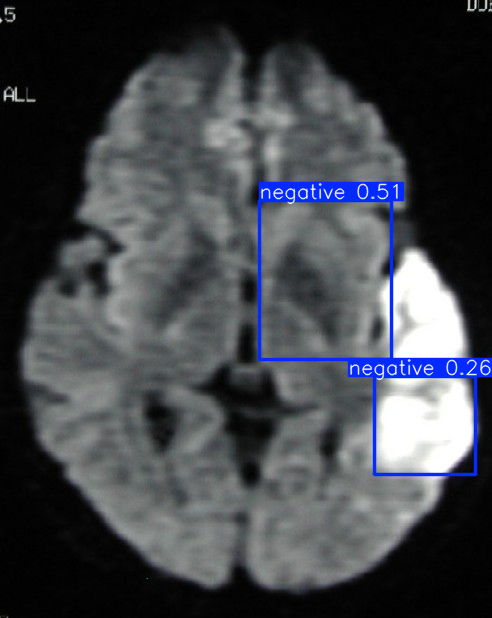

--------------------------------------------------


In [ ]:
import os
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

# 1. Eğittiğiniz ve Drive'a kaydettiğimiz EN İYİ (Best) modeli yükleyin
model_yolu = "/content/drive/MyDrive/Beyin_Tumoru_Projesi/YOLOv8n_Hoca_Kisitli_Optimize_Model/weights/best.pt"
model = YOLO(model_yolu)

print("Lütfen test etmek istediğiniz MR görüntüsünü (.jpg, .jpeg, .png) yükleyin:")
# 2. Bilgisayarınızdan dosya seçme penceresini açar
uploaded = files.upload()

# 3. Yüklenen her bir resmi modele tahmin ettir ve karar ver
for filename in uploaded.keys():
    print(f"\n--- {filename} Analiz Ediliyor ---")

    # Modeli çalıştır (Güven eşiği conf=0.25)
    # verbose=False yaparak ekrandaki gereksiz log kalabalığını gizliyoruz
    results = model.predict(source=filename, save=True, conf=0.25, verbose=False)
    result = results[0]

    # 4. Modelin kutu (bounding box) bulup bulmadığını kontrol et
    if len(result.boxes) == 0:
        print("\n[SONUÇ]: Kesin bir tümör belirtisi saptanamadı (TÜMÖRSÜZ/TEMİZ).")
        print("Model bu görüntüde belirtilen güven eşiğinin üzerinde bir nesne tespit edemedi.")
    else:
        print(f"\n[SONUÇ]: Şüpheli lezyon/tümör alanı saptandı!")
        print(f"Toplam tespit edilen bölge sayısı: {len(result.boxes)}")

        # Saptanan her bir kutunun detaylarını yazdır
        for i, box in enumerate(result.boxes):
            cls_id = int(box.cls[0])       # Sınıf indeksi (0 veya 1)
            label = model.names[cls_id]    # Sınıf adı (negative veya positive)
            conf_score = float(box.conf[0]) * 100 # Güven skoru (%)

            print(f" -> Bölge {i+1}: Sınıf = {label}, Modelin Güven Skoru = %{conf_score:.2f}")

    # 5. Çıktı klasörünü yazdır ve Görseli doğrudan Colab Ekranında Göster
    print(f"\nAnaliz çıktısı şu klasöre kaydedildi: {result.save_dir}")

    # Result içindeki plot() fonksiyonu bize çizilmiş resmi array olarak verir
    tahmin_resmi = result.plot()
    cv2_imshow(tahmin_resmi)
    print("-" * 50) # Alt çizgi çekerek bitir